In [1]:
from turtledemo.chaos import plot

import confusion_matrix
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor

None


In [2]:
data = pd.read_csv("diseases.csv")

In [3]:
data.shape

(768, 9)

In [4]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


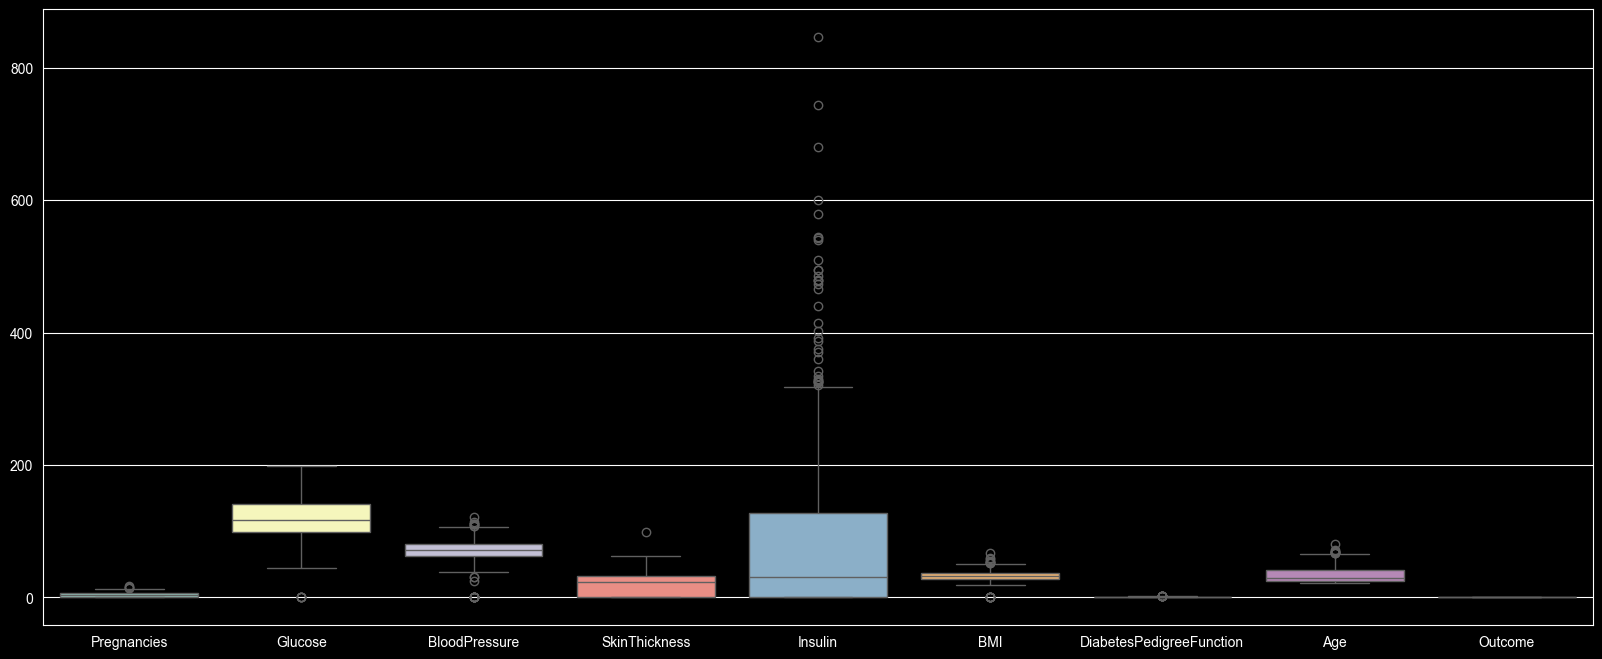

In [7]:
plt.figure(figsize=(20,8))
sns.boxplot(data=data)
plt.show()

In [8]:
q=data['Pregnancies'].quantile(0.98)
data_cleaned=data[data['Pregnancies']<q]

In [9]:
q=data['BMI'].quantile(0.99)
data_cleaned=data_cleaned[data_cleaned['BMI']<q]

In [10]:
q=data['SkinThickness'].quantile(0.99)
data_cleaned=data_cleaned[data_cleaned['SkinThickness']<q]

In [11]:
q=data['Insulin'].quantile(0.95)
data_cleaned=data_cleaned[data_cleaned['Insulin']<q]

In [12]:
q=data['DiabetesPedigreeFunction'].quantile(0.99)
data_cleaned=data_cleaned[data_cleaned['DiabetesPedigreeFunction']<q]

In [13]:
q=data['Age'].quantile(0.99)
data_cleaned=data_cleaned[data_cleaned['Age']<q]

In [14]:
data_cleaned.shape

(680, 9)

C:\Users\VANSHITHA\AppData\Local\Temp\ipykernel_19668\2144235276.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_cleaned[column])
C:\Users\VANSHITHA\AppData\Local\Temp\ipykernel_19668\2144235276.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_cleaned[column])
C:\Users\VANSHITHA

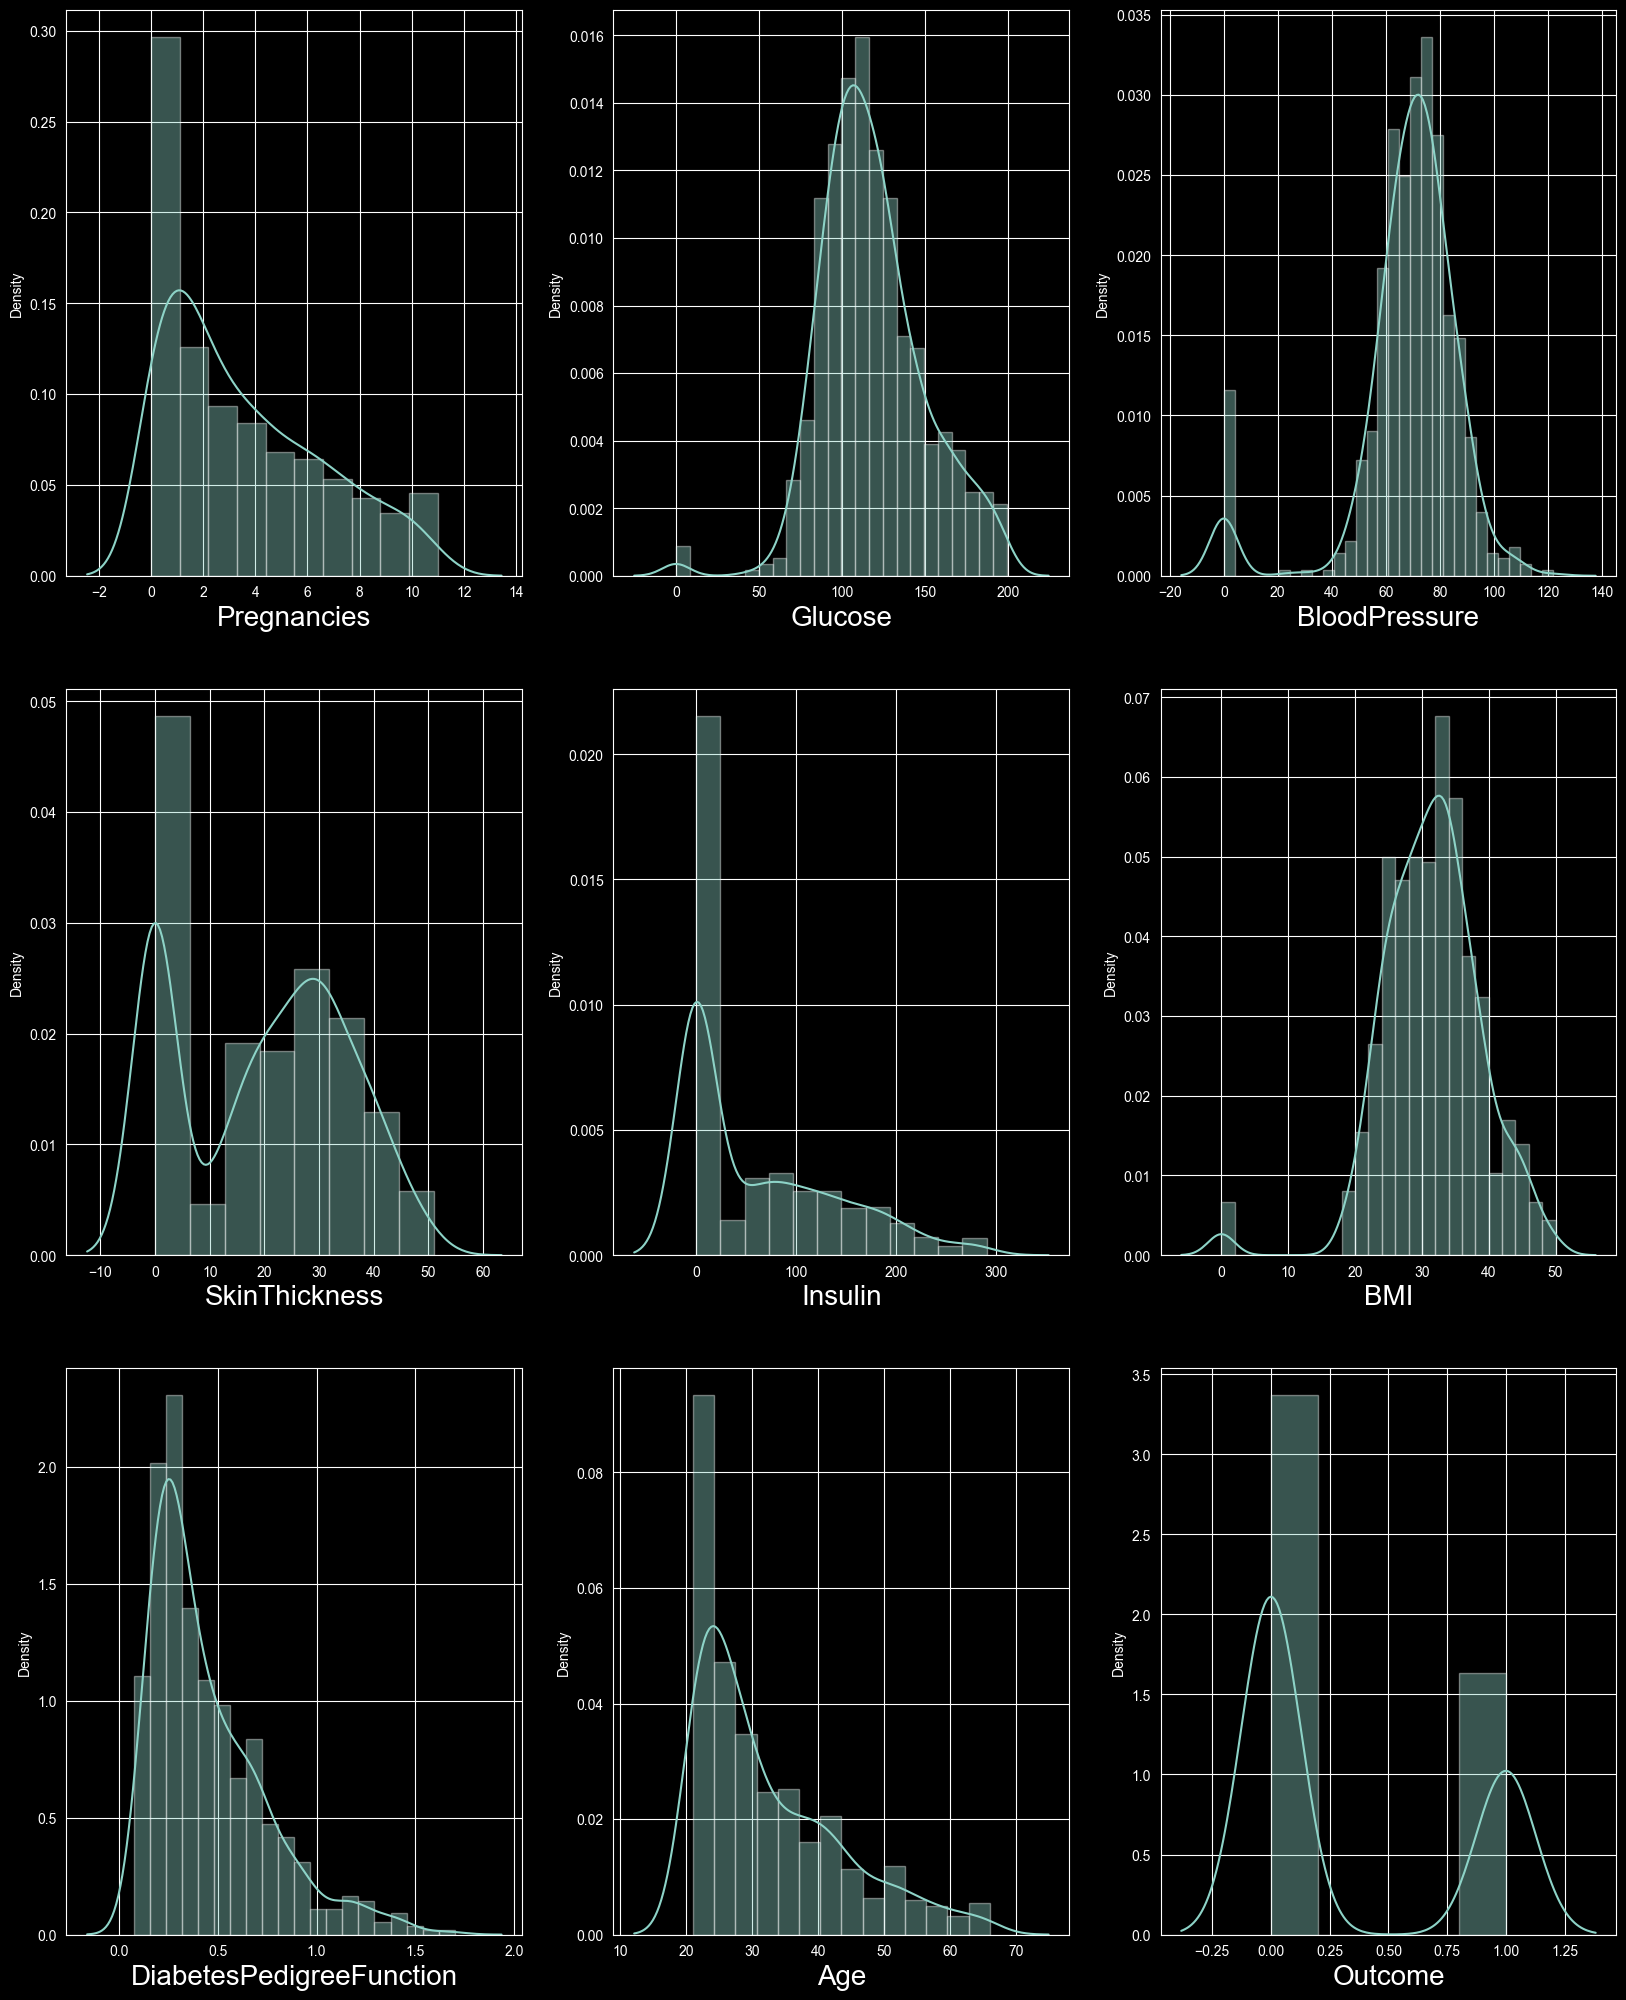

In [15]:
plt.figure(figsize=(20,25),facecolor='black')
plotnumber=1

for column in data_cleaned:
    if plotnumber<=9:
        ax=plt.subplot(3,3,plotnumber)
        sns.distplot(data_cleaned[column])
        plt.xlabel(column,fontsize=20)
    plotnumber+=1
plt.show()

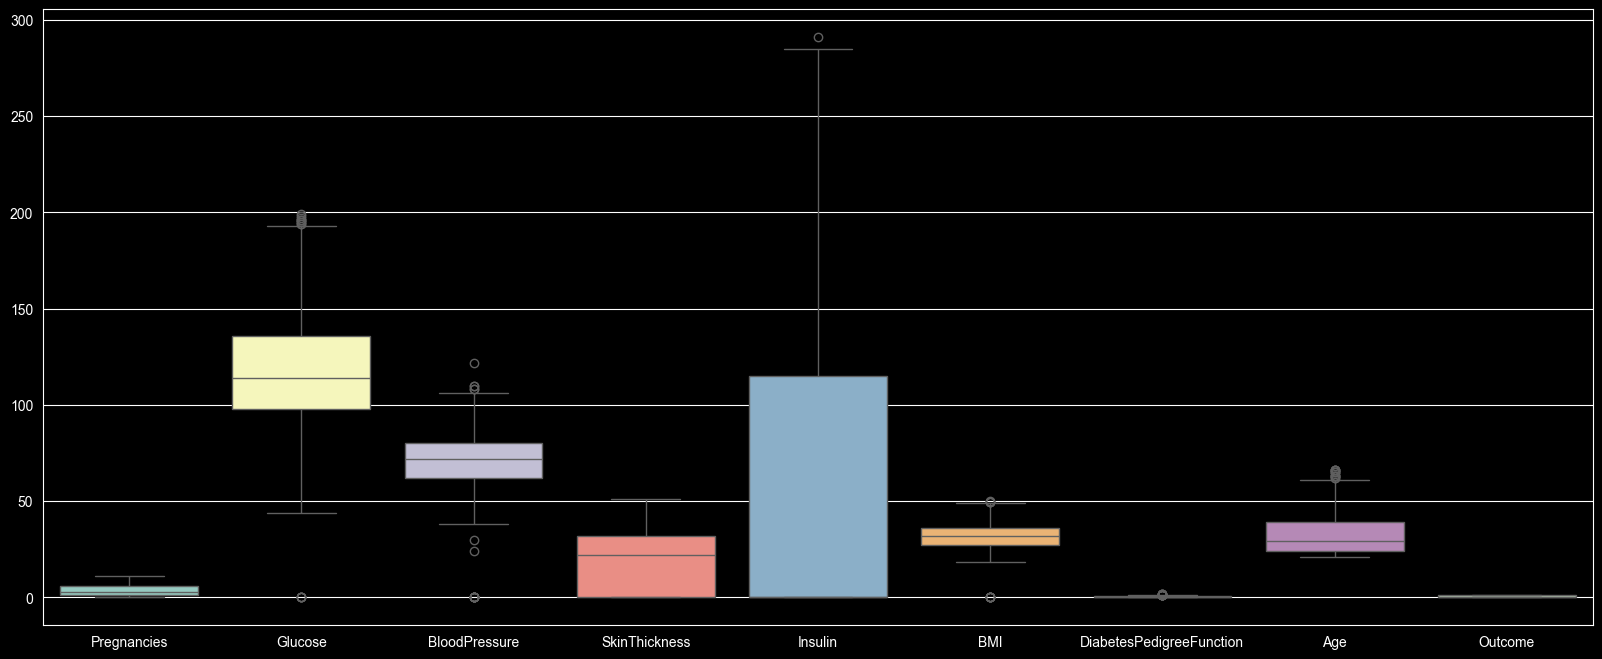

In [16]:
plt.figure(figsize=(20,8))
sns.boxplot(data=data_cleaned)
plt.show()

In [17]:
data_cleaned['BMI']=data_cleaned['BMI'].replace(0,data_cleaned['BMI'].mean())
data_cleaned['BloodPressure']=data_cleaned['BloodPressure'].replace(0,data_cleaned['BloodPressure'].mean())
data_cleaned['Insulin']=data_cleaned['Insulin'].replace(0,data_cleaned['Insulin'].mean())
data_cleaned['SkinThickness']=data_cleaned['SkinThickness'].replace(0,data_cleaned['SkinThickness'].mean())
data_cleaned['Glucose']=data_cleaned['Glucose'].replace(0,data_cleaned['Glucose'].mean())


In [18]:
data_cleaned

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.000000,60.748529,33.6,0.627,50,1
1,1,85.0,66.0,29.000000,60.748529,26.6,0.351,31,0
2,8,183.0,64.0,19.482353,60.748529,23.3,0.672,32,1
3,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21,0
5,5,116.0,74.0,19.482353,60.748529,25.6,0.201,30,0
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.000000,180.000000,32.9,0.171,63,0
764,2,122.0,70.0,27.000000,60.748529,36.8,0.340,27,0
765,5,121.0,72.0,23.000000,112.000000,26.2,0.245,30,0
766,1,126.0,60.0,19.482353,60.748529,30.1,0.349,47,1


C:\Users\VANSHITHA\AppData\Local\Temp\ipykernel_19668\2144235276.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_cleaned[column])
C:\Users\VANSHITHA\AppData\Local\Temp\ipykernel_19668\2144235276.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_cleaned[column])
C:\Users\VANSHITHA

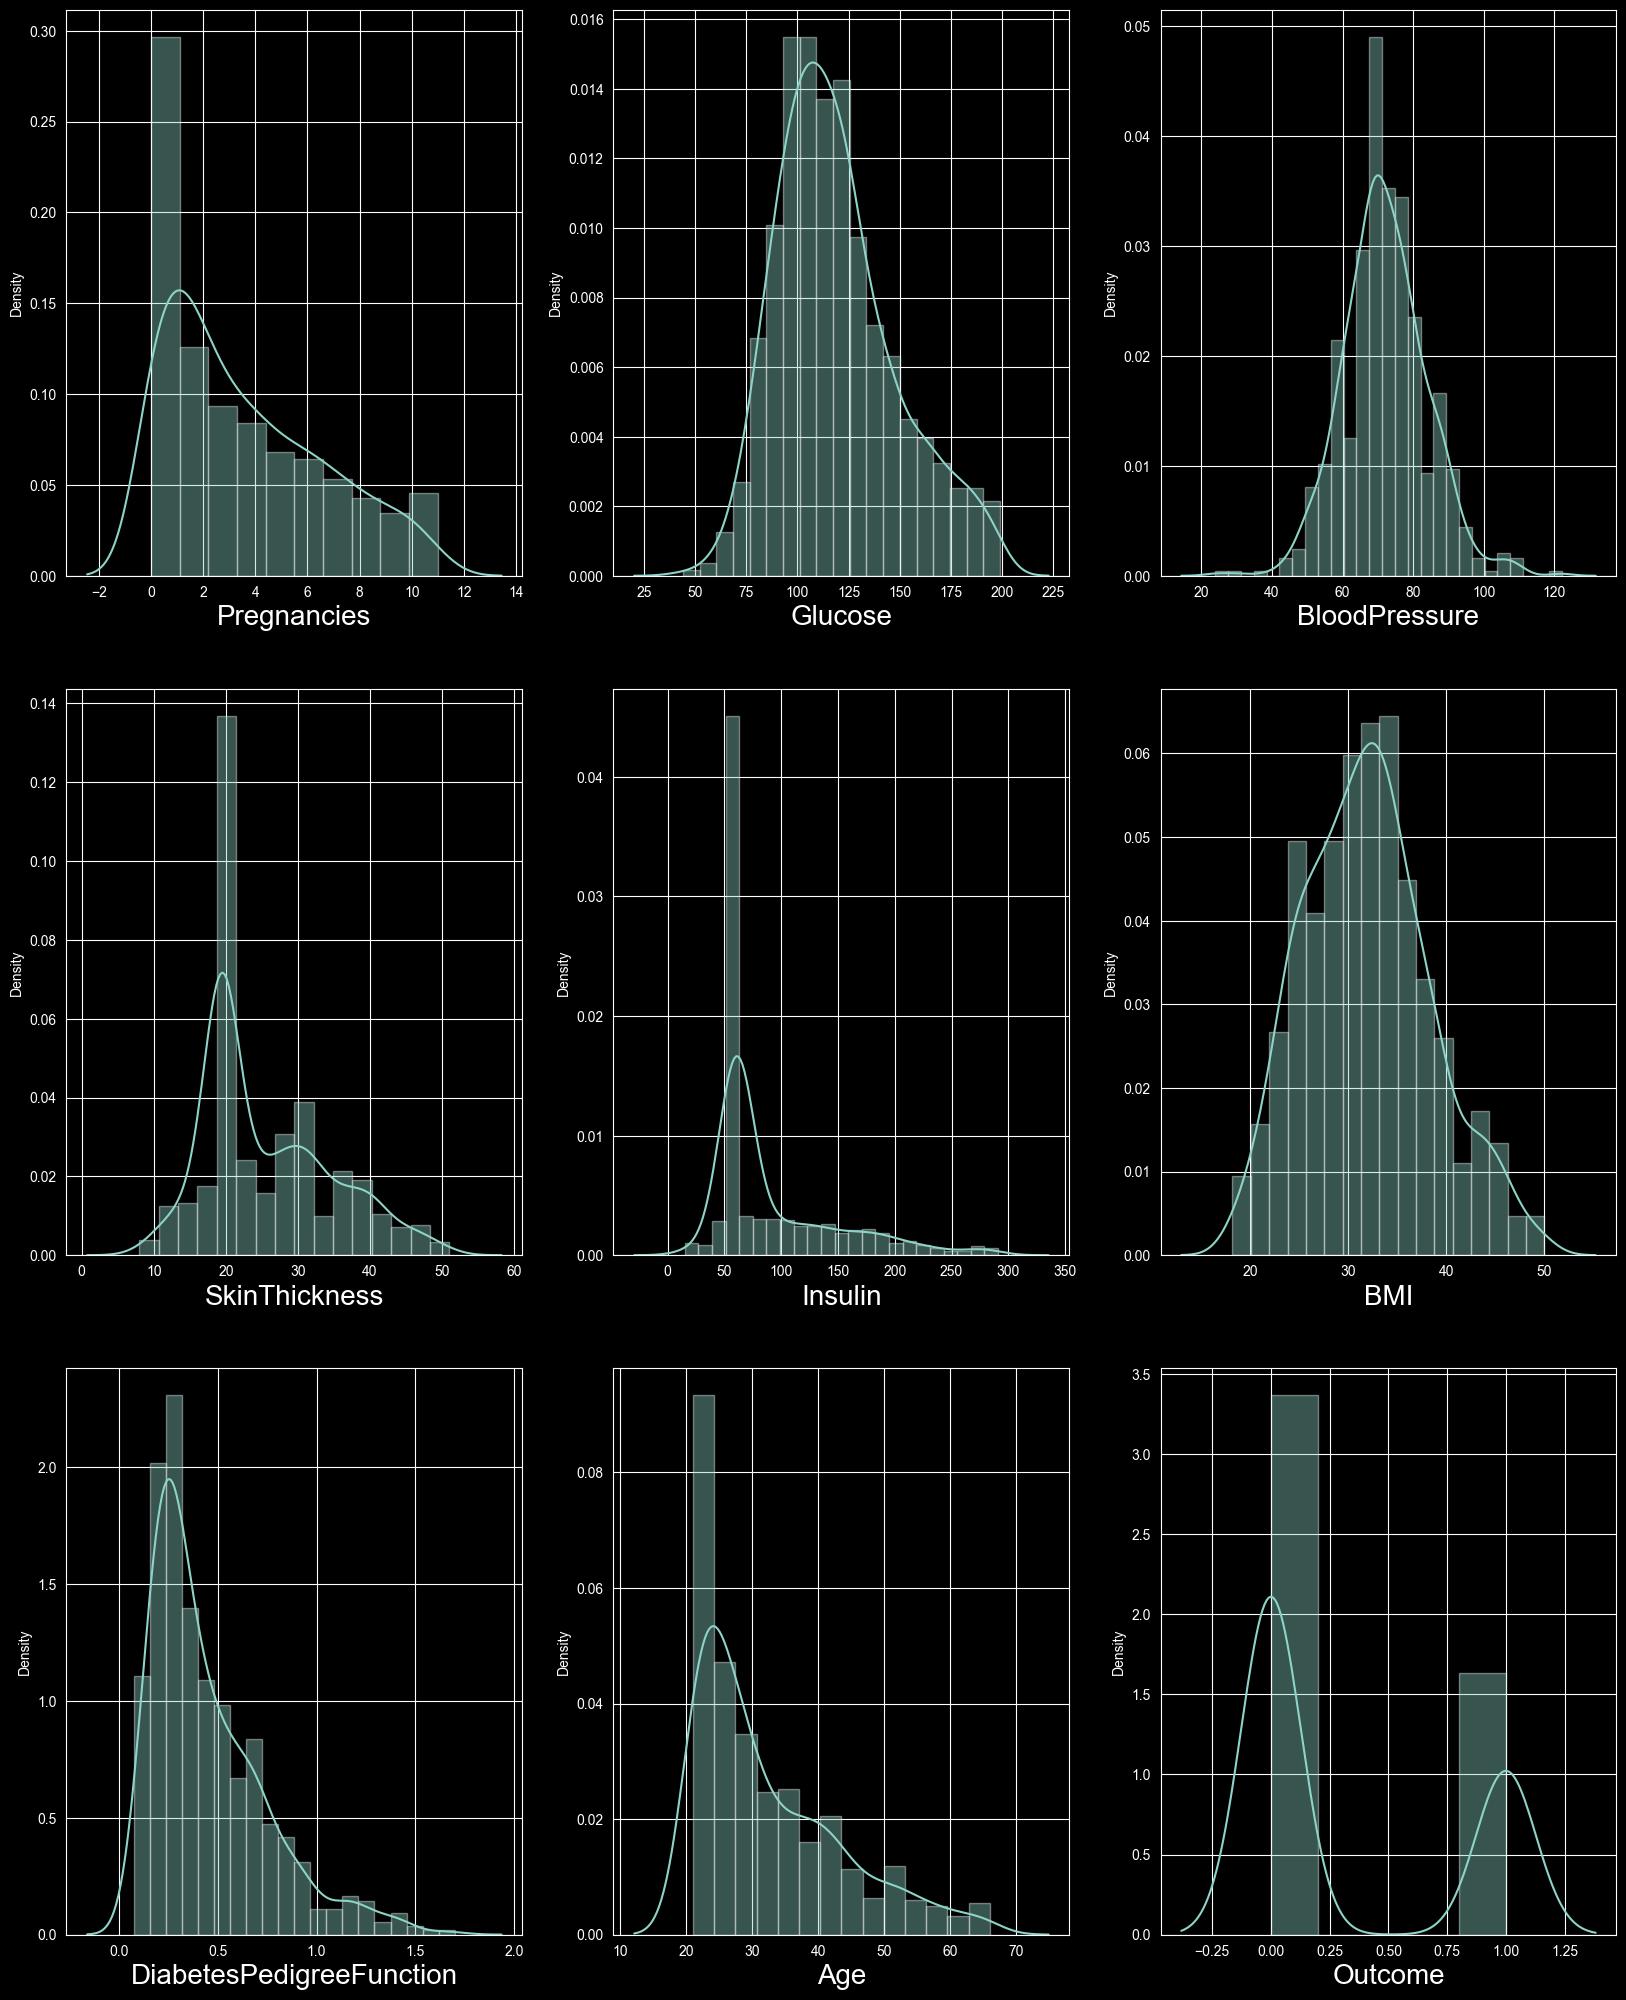

In [19]:
plt.figure(figsize=(20,25),facecolor='black')
plotnumber=1

for column in data_cleaned:
    if plotnumber<=9:
        ax=plt.subplot(3,3,plotnumber)
        sns.distplot(data_cleaned[column])
        plt.xlabel(column,fontsize=20)
    plotnumber+=1
plt.show()

In [20]:
x=data_cleaned.drop(columns=['Outcome'])
y=data_cleaned['Outcome']

In [21]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [22]:
scaler

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [23]:
x_scaled

array([[ 8.04654759e-01,  9.88860570e-01, -9.66160391e-04, ...,
         2.61046563e-01,  6.06952609e-01,  1.61068154e+00],
       [-8.60485948e-01, -1.16802016e+00, -5.06342365e-01, ...,
        -8.31519208e-01, -3.40465910e-01, -1.27396260e-01],
       [ 1.47071104e+00,  2.18712764e+00, -6.74801100e-01, ...,
        -1.34658593e+00,  7.61423019e-01, -3.59184808e-02],
       ...,
       [ 4.71626618e-01,  6.44831164e-02, -9.66160391e-04, ...,
        -8.93951538e-01, -7.04329544e-01, -2.18874039e-01],
       [-8.60485948e-01,  2.35664126e-01, -1.01171857e+00, ...,
        -2.85236323e-01, -3.47331262e-01,  1.33624820e+00],
       [-8.60485948e-01, -8.94130539e-01, -1.69424895e-01, ...,
        -2.38412075e-01, -4.64042238e-01, -8.59218491e-01]],
      shape=(680, 8))

In [24]:
variables=x_scaled

In [25]:
vif=pd.DataFrame()

In [26]:
vif

""


In [27]:
vif['VIF']=[variance_inflation_factor(variables,i)for i in range(variables.shape[1])]
vif['Features']=x.columns

In [28]:
vif

,VIF,Features
0,1.454546,Pregnancies
1,1.289531,Glucose
2,1.265376,BloodPressure
3,1.506651,SkinThickness
4,1.295090,Insulin
5,1.512380,BMI
6,1.044950,DiabetesPedigreeFunction
7,1.668142,Age


<Axes: >

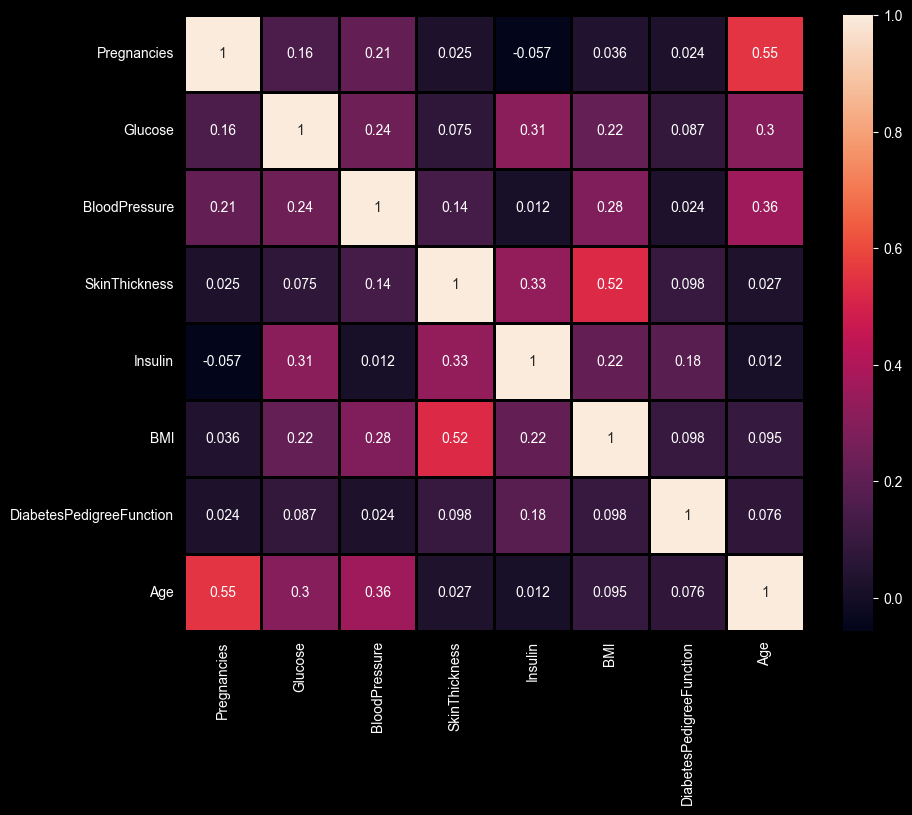

In [29]:
plt.figure(figsize=(10,8))
sns.heatmap(x.corr(numeric_only=True),annot=True,linecolor='black',linewidths=2)

In [30]:
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.000000,60.748529,33.6,0.627,50
1,1,85.0,66.0,29.000000,60.748529,26.6,0.351,31
2,8,183.0,64.0,19.482353,60.748529,23.3,0.672,32
3,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21
5,5,116.0,74.0,19.482353,60.748529,25.6,0.201,30
...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.000000,180.000000,32.9,0.171,63
764,2,122.0,70.0,27.000000,60.748529,36.8,0.340,27
765,5,121.0,72.0,23.000000,112.000000,26.2,0.245,30
766,1,126.0,60.0,19.482353,60.748529,30.1,0.349,47


In [31]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [32]:
x_train.shape

(544, 8)

In [33]:
from sklearn.linear_model import LogisticRegression
regression=LogisticRegression()
regression.fit(x_train,y_train)

C:\Users\VANSHITHA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [34]:
regression.predict(x_test)

array([1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0])

In [35]:
y_pred= regression.predict(x_test)
y_pred

array([1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0])

In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred))



Logistic Regression Results
Accuracy: 0.7941176470588235


In [37]:
conf_mat=confusion_matrix(y_test, y_pred)


In [38]:
true_positive=conf_mat[0][0]
false_positive=conf_mat[0][1]
false_negative=conf_mat[1][0]
true_negative=conf_mat[1][1]

In [39]:
Acc=(true_positive+true_negative)/(true_positive+true_negative+false_positive+false_negative)
Acc

np.float64(0.7941176470588235)

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7647058823529411


In [41]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

y_pred_knn = knn.predict(x_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.7573529411764706


In [42]:
#Logistic Regression is better than these

In [43]:
import pickle
pickle.dump(regression, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [44]:
pip install flask flask-mysqldb



   ---------------------------------------- 0/9 [mysqlclient]
   ---------------------------------------- 0/9 [mysqlclient]
   ---- ----------------------------------- 1/9 [markupsafe]
   -------- ------------------------------- 2/9 [itsdangerous]
   -------- ------------------------------- 2/9 [itsdangerous]
   ------------- -------------------------- 3/9 [click]
   ------------- -------------------------- 3/9 [click]
   ------------- -------------------------- 3/9 [click]
   ------------- -------------------------- 3/9 [click]
   ----------------- ---------------------- 4/9 [blinker]
   ---------------------- ----------------- 5/9 [werkzeug]
   ---------------------- ----------------- 5/9 [werkzeug]
   ---------------------- ----------------- 5/9 [werkzeug]
   ---------------------- ----------------- 5/9 [werkzeug]
   ---------------------- ----------------- 5/9 [werkzeug]
   ---------------------- ----------------- 5/9 [werkzeug]
   ---------------------- ----------------- 5/9 [wer


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
